In [1]:
import pandas as pd
import numpy as np

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/traffic_density_timeseries.csv")

df.head()

,time_bin_5m,vehicle_count,avg_speed,pce_volume,crawling_count,hard_braking_count
0,2018-10-24 08:30:00,4724,17.826713,4383.0,3427,1419
1,2018-10-24 08:35:00,5106,17.355170,4733.0,3816,1654
2,2018-10-24 08:40:00,3905,16.790361,3633.5,2907,1174
3,2018-10-24 09:00:00,4620,14.779216,4308.0,3809,1441
4,2018-10-24 09:05:00,4983,14.968209,4627.0,4016,1578


In [3]:
print(df.shape)

df.info()

(68, 6)
<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time_bin_5m         68 non-null     str    
 1   vehicle_count       68 non-null     int64  
 2   avg_speed           68 non-null     float64
 3   pce_volume          68 non-null     float64
 4   crawling_count      68 non-null     int64  
 5   hard_braking_count  68 non-null     int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 3.3 KB


In [4]:
prophet_df = df[
    ["time_bin_5m", "vehicle_count"]
].copy()

prophet_df.columns = [
    "ds",
    "y"
]

prophet_df.head()

,ds,y
0,2018-10-24 08:30:00,4724
1,2018-10-24 08:35:00,5106
2,2018-10-24 08:40:00,3905
3,2018-10-24 09:00:00,4620
4,2018-10-24 09:05:00,4983


In [5]:
prophet_df["ds"] = pd.to_datetime(
    prophet_df["ds"]
)

prophet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      68 non-null     datetime64[us]
 1   y       68 non-null     int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 1.2 KB


In [6]:
prophet_df.head()

,ds,y
0,2018-10-24 08:30:00,4724
1,2018-10-24 08:35:00,5106
2,2018-10-24 08:40:00,3905
3,2018-10-24 09:00:00,4620
4,2018-10-24 09:05:00,4983


In [7]:
split_idx = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:split_idx]
test = prophet_df.iloc[split_idx:]

print("Train:", len(train))
print("Test :", len(test))

Train: 54
Test : 14


In [8]:
model = Prophet()

model.fit(train)

02:13:23 - cmdstanpy - INFO - Chain [1] start processing
02:13:24 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
future = model.make_future_dataframe(
    periods=len(test),
    freq="5min"
)

future.tail()

,ds
63,2018-11-01 09:20:00
64,2018-11-01 09:25:00
65,2018-11-01 09:30:00
66,2018-11-01 09:35:00
67,2018-11-01 09:40:00


In [10]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-10-24 08:30:00,6437.449358,2149.272154,5456.187948,6437.449358,6437.449358,-2508.540170,-2508.540170,-2508.540170,-2508.540170,-2508.540170,-2508.540170,0.0,0.0,0.0,3928.909188
1,2018-10-24 08:35:00,6436.867526,2306.913019,5555.892955,6436.867526,6436.867526,-2475.677799,-2475.677799,-2475.677799,-2475.677799,-2475.677799,-2475.677799,0.0,0.0,0.0,3961.189727
2,2018-10-24 08:40:00,6436.285695,2359.949052,5743.255539,6436.285695,6436.285695,-2410.865860,-2410.865860,-2410.865860,-2410.865860,-2410.865860,-2410.865860,0.0,0.0,0.0,4025.419834
3,2018-10-24 09:00:00,6433.958369,2979.817932,6033.732161,6433.958369,6433.958369,-1967.338908,-1967.338908,-1967.338908,-1967.338908,-1967.338908,-1967.338908,0.0,0.0,0.0,4466.619461
4,2018-10-24 09:05:00,6433.376537,2931.918282,6209.338701,6433.376537,6433.376537,-1842.680453,-1842.680453,-1842.680453,-1842.680453,-1842.680453,-1842.680453,0.0,0.0,0.0,4590.696084


In [11]:
forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
63,2018-11-01 09:20:00,3563.897716,2021.658611,5112.636118
64,2018-11-01 09:25:00,3632.202354,2003.161543,5190.325045
65,2018-11-01 09:30:00,3675.735191,2081.679018,5291.907194
66,2018-11-01 09:35:00,3691.275252,2075.987178,5330.000020
67,2018-11-01 09:40:00,3676.214669,1942.187648,5133.699241


In [12]:
pred = forecast[
    ["ds", "yhat"]
].tail(len(test))

pred.head()

,ds,yhat
54,2018-11-01 08:35:00,2621.584622
55,2018-11-01 08:40:00,2685.815826
56,2018-11-01 08:45:00,2775.146981
57,2018-11-01 08:50:00,2882.819180
58,2018-11-01 08:55:00,3002.233838


In [13]:
results = test.merge(
    pred,
    on="ds"
)

results.head()

,ds,y,yhat
0,2018-11-01 08:35:00,4443,2621.584622
1,2018-11-01 08:40:00,3913,2685.815826
2,2018-11-01 08:45:00,318,2775.146981
3,2018-11-01 09:00:00,4374,3127.019832
4,2018-11-01 09:05:00,4524,3251.097551


In [14]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [15]:
mae = mean_absolute_error(
    results["y"],
    results["yhat"]
)

rmse = np.sqrt(
    mean_squared_error(
        results["y"],
        results["yhat"]
    )
)

mape = np.mean(
    np.abs(
        (results["y"] - results["yhat"])
        / results["y"]
    )
) * 100

r2 = r2_score(
    results["y"],
    results["yhat"]
)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")
print("R2  :", round(r2, 4))

MAE : 1453.53
RMSE: 1616.63
MAPE: 152.83 %
R2  : -0.0032


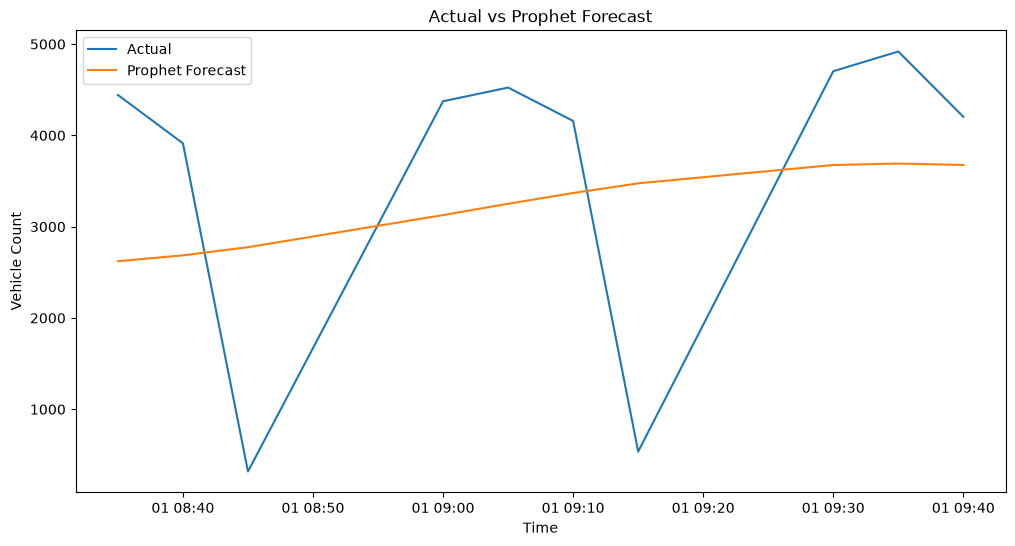

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    results["ds"],
    results["y"],
    label="Actual"
)

plt.plot(
    results["ds"],
    results["yhat"],
    label="Prophet Forecast"
)

plt.legend()

plt.title("Actual vs Prophet Forecast")

plt.xlabel("Time")
plt.ylabel("Vehicle Count")

plt.show()